In [10]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [27]:
import gc

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from sam.segment_anything import SamPredictor, SamAutomaticMaskGenerator, build_sam_vit_h # glad it works with out of directory imports too :)
from PIL import Image

In [15]:
model = SamAutomaticMaskGenerator(build_sam_vit_h(r"./bin/sam_vit_h_4b8939.pth"))

In [17]:
Image.open(r"./images/dog.jpg").mode

'RGB'

In [19]:
dog_pil = np.array(Image.open(r"./images/dog.jpg"), dtype=np.uint8)
dog_cv2 = cv2.imread(r"./images/dog.jpg")

In [20]:
(dog_pil == dog_cv2).mean()

np.float64(0.3448813982521848)

In [21]:
(dog_pil == cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB)).mean() # OpenCV reads in images in BGR colour channels by default but PIL uses RGB channel by default

np.float64(1.0)

In [22]:
masks_pil = model.generate(dog_pil)
masks_cv2 = model.generate(cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB))

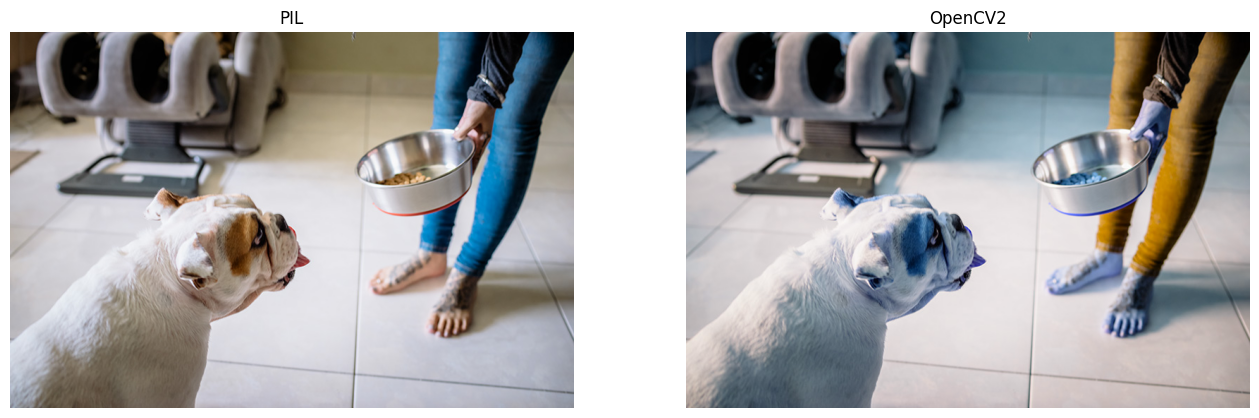

In [24]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")

plt.show()

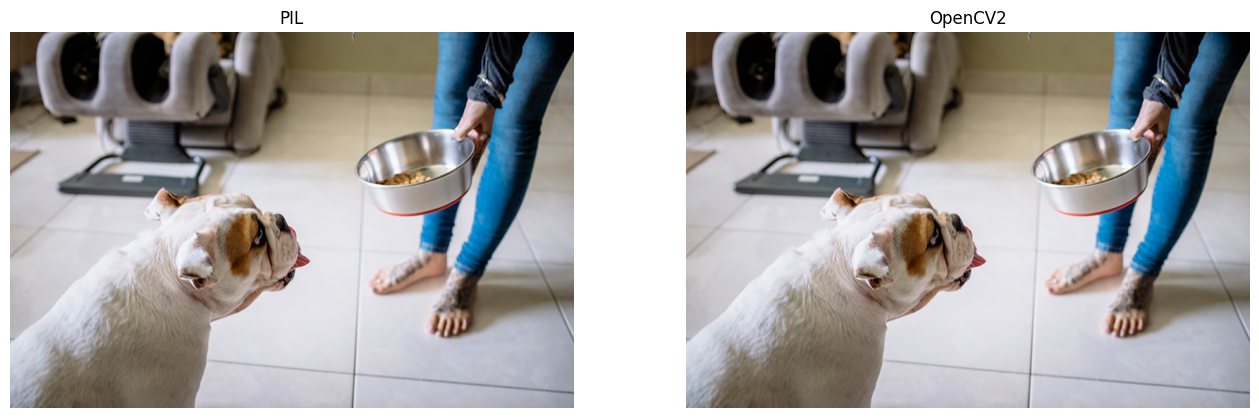

In [25]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")

axis_r.imshow(cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB)) # with colour channel transformation
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")

plt.show()

In [26]:
masks_pil

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ..., False, False, False],
         [False, False, False, ..., False, False, False]], shape=(534, 800)),
  'area': 76377,
  'bbox': [0, 223, 422, 309],
  'predicted_iou': 1.0341997146606445,
  'point_coords': [[362.5, 258.65625]],
  'stability_score': 0.9911314249038696,
  'crop_box': [0, 0, 800, 534]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ...,  True,  True,  True],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]], shape=(534, 800)),
  'a

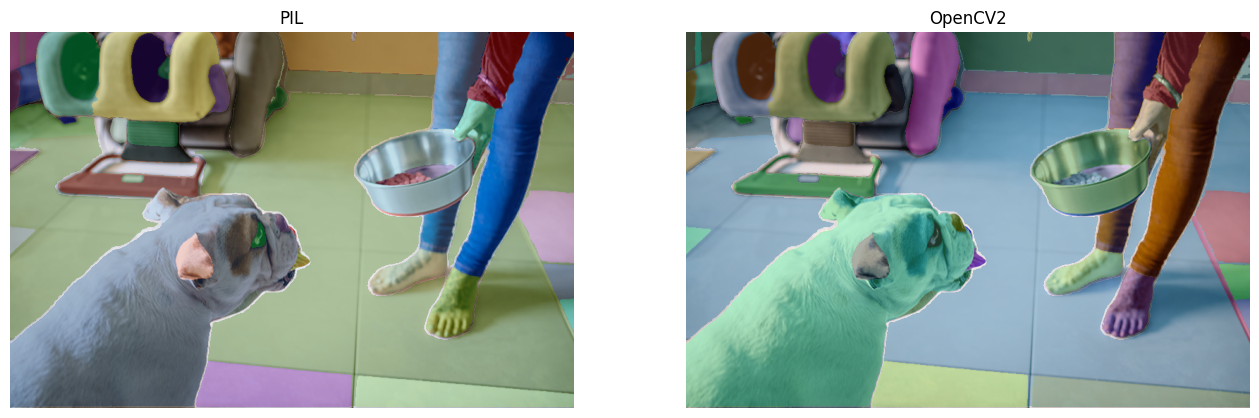

In [13]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")
show_anns(masks_pil, ax=axis_l)

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")
show_anns(masks_cv2, ax=axis_r)

plt.show()